In [33]:
from pathlib import Path
import pandas as pd
import numpy as np
import umap
import umap.plot
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.stream_3.gen_hdb_clus import GenerateHDBSCAN2
from src.stream_3.gen_umap_emb import GenerateUmapEmb2
from src.loading_data.load_data import get_master_clustering_input
from src.loading_data.data_catalogue import DataCatalogue
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [63]:
np.unique(np.round(np.logspace(np.log10(10), np.log10(500), 10)).astype(int))

array([ 10,  15,  24,  37,  57,  88, 136, 210, 324, 500])

In [ ]:
run_cases = {
    # Adjust continuous
    0 : {'continuous_neighbors' : 50, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 100, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 150, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 200, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 250, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 300, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 350, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 400, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 450, 'categorical_neighbors' : 50},
    0 : {'continuous_neighbors' : 500, 'categorical_neighbors' : 50},

    
    0 : {'continuous_neighbors' : 100, 'categorical_neighbors' : 100}
}

In [14]:
df = get_master_clustering_input()
df.columns

Master data loaded with zero missing values.


Index(['Age9', 'Gend3', 'Eth7', 'Disab2_POP', 'Educ6', 'NSSEC5', 'IMD10',
       'WorkStat8', 'Child4', 'HHLiv9', 'Motiva_POP', 'motivd_POP'],
      dtype='str')

In [15]:
dc = DataCatalogue()
dc.get_clustering_continuous()

['Age9', 'NSSEC5', 'Educ6', 'IMD10', 'Child4', 'Motiva_POP', 'motivd_POP']

In [16]:
dc.get_clustering_categoricals()

['Gend3', 'Disab2_POP', 'Eth7', 'WorkStat8', 'HHLiv9']

In [17]:
continuous = dc.get_clustering_continuous()
categorical = dc.get_clustering_categoricals()
emb_generator = GenerateUmapEmb2()
umap_instance = emb_generator.fit_fuzzy_umap(
    df = df, 
    avail_contins=continuous, 
    avail_cats=categorical, 
    continuous_neighbors = 250, 
    categorical_neighbors = 100,
    continuous_metric= 'euclidean',
    categorical_metric= 'jaccard',
    operator = '+'
    )

Save path found.
Continuous Shape: (85659, 7)
Categorical Shape: (85659, 29)
Finished fitting continuous....


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(


Finished fitting categorical...
Computing fuzzy set intersection...
Finished computing intersection...
UMAP fit complete!
Embedding saved to
 C:\Users\fergu\Documents\GitHub\london_sport2\src\stream_3\embeddings


<Axes: >

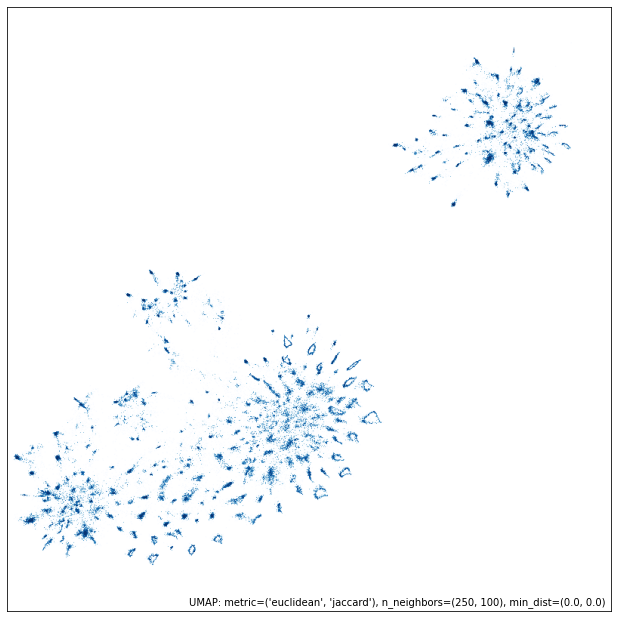

In [18]:
umap.plot.points(umap_instance)

In [19]:
hdb = GenerateHDBSCAN2()
hdb.fit(umap_instance.embedding_)

100%|██████████| 11/11 [08:18<00:00, 45.35s/it]


     min_sample  min_cluster cluster_selection     metric  num_clusters  \
197          40          500               eom  manhattan            16   
193          40          450               eom  manhattan            18   
312          70          450               eom  euclidean            17   
348          80          400               eom  euclidean            20   
272          60          450               eom  euclidean            17   
233          50          450               eom  manhattan            10   
237          50          500               eom  manhattan             9   
277          60          500               eom  manhattan             4   
273          60          450               eom  manhattan             4   
156          30          500               eom  euclidean             4   

     unclustered_prop      dbcv  
197          0.104379  0.781648  
193          0.099056  0.774445  
312          0.086728  0.756462  
348          0.083914  0.750781  
272 

C:\Users\fergu\AppData\Local\Temp\ipykernel_34176\616345750.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


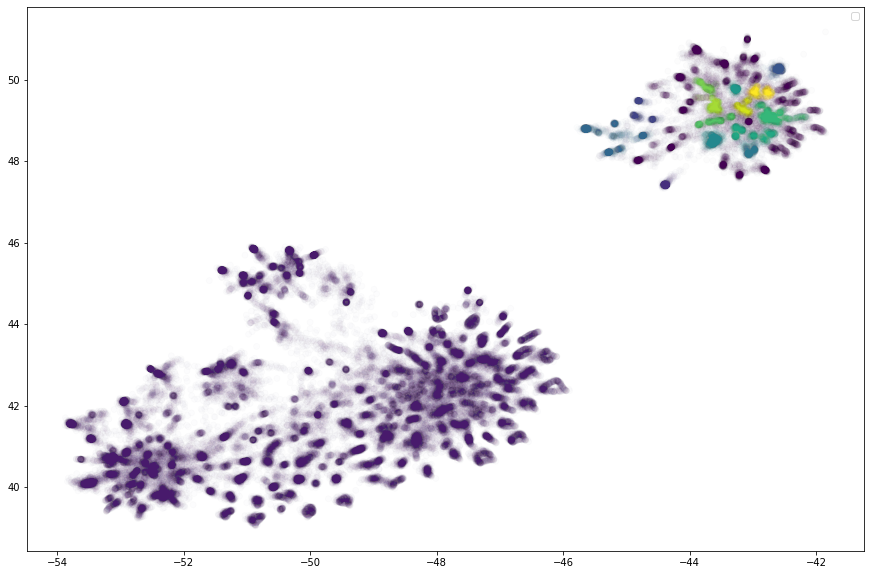

In [ ]:
plt.figure(figsize=(15,10))
plt.scatter(umap_instance.embedding_[:,0], umap_instance.embedding_[:,1], alpha=0.01, c=hdb.get_model().labels_)
plt.legend()

<Axes: >

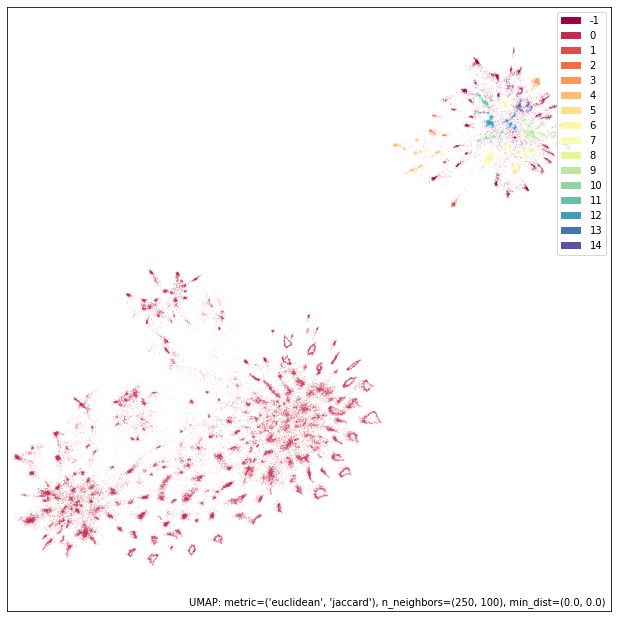

In [54]:
umap.plot.points(umap_instance, labels = hdb.get_model().labels_)

<Axes: ylabel='$\\lambda$ value'>

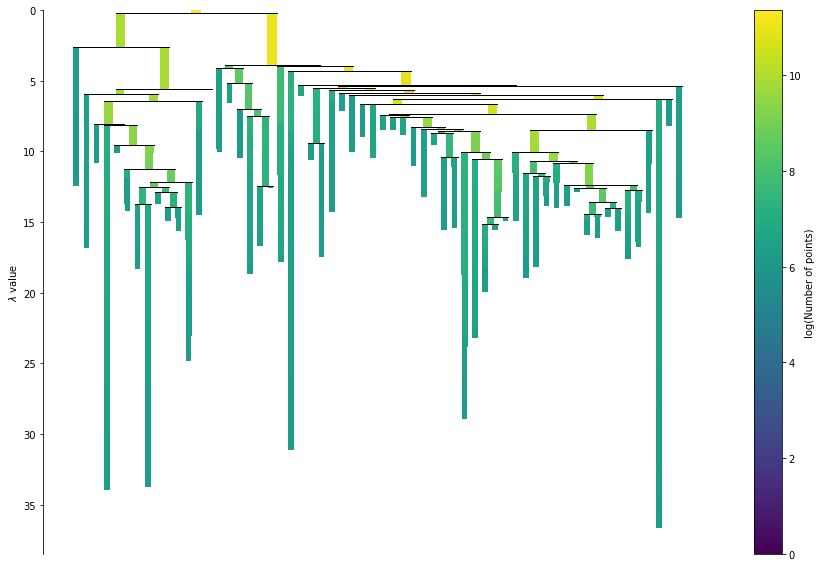

In [53]:
plt.figure(figsize=(15,10))
hdb.get_model().condensed_tree_.plot(select_clusters=False, log_size=True)

In [22]:
pd.Series(hdb.get_model().labels_).value_counts().sort_index()

-1      8941
 0     65040
 1       538
 2       550
 3       633
 4      1540
 5       554
 6      1163
 7       508
 8      1120
 9      1545
 10      648
 11      626
 12      995
 13      567
 14      691
Name: count, dtype: int64

In [23]:
df['labels'] = hdb.get_model().labels_

In [39]:
pd.set_option('display.max_rows', None)

In [40]:
eth = df.groupby(['labels', 'Eth7'])['Eth7'].count()

In [41]:
hh_liv = df.groupby(['labels', 'HHLiv9'])['HHLiv9'].count()

In [42]:
workstat = df.groupby(['labels', 'WorkStat8'])['WorkStat8'].count()

In [43]:
print(eth)

labels  Eth7
-1      0        3826
        1        1227
        2        1931
        3        1178
        4         146
        5         354
        6         279
 0      0       38247
        1       10691
        2        7130
        3        3597
        4        1503
        5        2240
        6        1632
 1      0         538
 2      0         203
        1          12
        2         334
        4           1
 3      0         629
        3           1
        5           3
 4      0         666
        1         242
        3         439
        4          20
        5          87
        6          86
 5      0         521
        1           2
        2           3
        3           4
        4          12
        5           1
        6          11
 6      0          15
        1        1138
        2           4
        3           2
        5           3
        6           1
 7      0          14
        1          17
        2         469
        3          

In [44]:
print(hh_liv)

labels  HHLiv9
-1      0             1
        1             4
        2           964
        4          7334
        5            20
        6           367
        7            10
        8           241
 0      0         18759
        1          5165
        2          1947
        3         23521
        4            35
        5          5534
        6           626
        7          6455
        8          2998
 1      2           538
 2      2           538
        8            12
 3      1             2
        4           593
        6            21
        7             1
        8            16
 4      1             5
        2          1467
        5             9
        6            24
        8            35
 5      4           553
        6             1
 6      2             7
        4          1139
        6             6
        8            11
 7      4           508
 8      4          1112
        6             3
        8             5
 9      4          1545
 

In [45]:
print(workstat)

labels  WorkStat8
-1      0             4366
        1             2301
        2              357
        3               53
        4             1337
        5              102
        6               96
        7              329
 0      0            31838
        1             7597
        2             2736
        3            14158
        4              823
        5             1410
        6             4620
        7             1858
 1      0              538
 2      0              327
        1              116
        2               27
        3                9
        4               48
        5                3
        6                4
        7               16
 3      3                1
        4              624
        6                8
 4      1              979
        2              189
        3               12
        4              249
        5               13
        6               33
        7               65
 5      0              174
        1 

In [32]:
cluster_profiles = df.groupby('labels').agg({
    'Disab2_POP' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'Educ6' : 'mean',
    'IMD10' : 'mean',
    'Motiva_POP' : 'mean',
    'motivd_POP' : 'mean',
})

<Axes: >

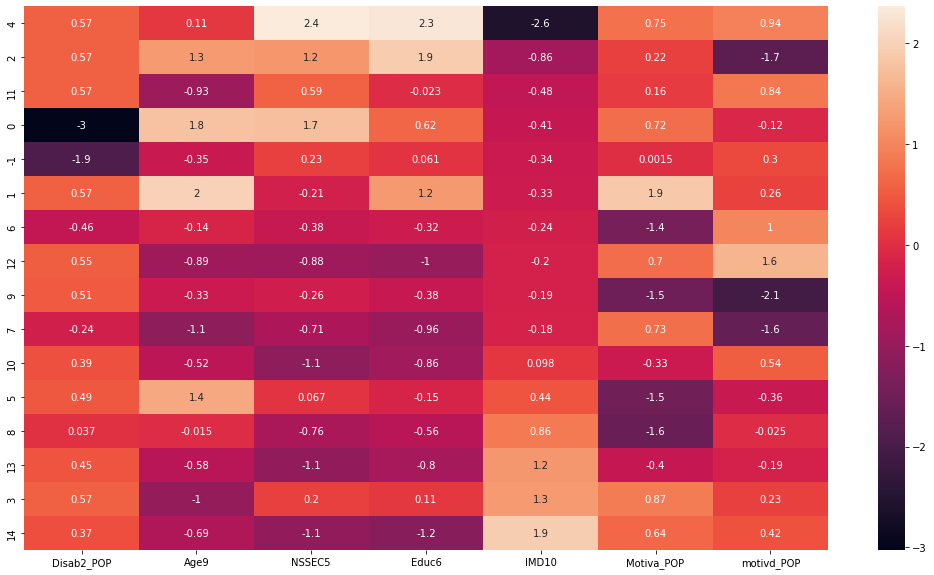

In [34]:
scaler = StandardScaler()
sorted_cluster_profiles = cluster_profiles.sort_values('IMD10')
heat = scaler.fit_transform(sorted_cluster_profiles)
plt.figure(figsize=(18,10))
sns.heatmap(
    heat, 
    annot=True,
    xticklabels = sorted_cluster_profiles.columns,
    yticklabels = sorted_cluster_profiles.index
)

labels  Eth7
-1      0          0
        1       1227
        2       3862
        3       3534
        4        584
                ... 
 14     2        116
        3         15
        4         36
        5         35
        6         42
Name: Eth7, Length: 88, dtype: int64

In [46]:
hdb.get_model().probabilities_

array([1., 1., 1., ..., 1., 1., 0.], shape=(85659,))

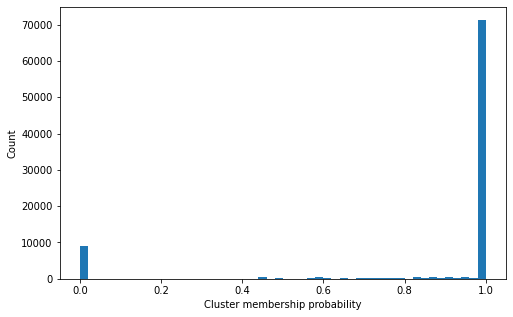

In [47]:
probs = hdb.get_model().probabilities_
plt.figure(figsize=(8,5))
plt.hist(probs, bins=50)
plt.xlabel('Cluster membership probability')
plt.ylabel('Count')
plt.show()